# Linear & Logistic Regression: A Step‑by‑Step Tutorial

1. **Linear Regression** (from intuition → loss → optimization → evaluation → regularization).
2. **Logistic Regression** (from classification intuition → sigmoid/likelihood → optimization → evaluation → multiclass).



## 0. Environment & Utilities

This section imports the libraries used throughout. No internet access is required; all datasets used are provided by `scikit-learn` or are synthetically generated.


In [ ]:

# Core libraries
import math
import numpy as np
import matplotlib.pyplot as plt

# Data and models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, precision_recall_fscore_support, classification_report
from sklearn.datasets import load_breast_cancer, load_iris

# For reproducibility
np.random.seed(42)

# Matplotlib defaults (avoid seaborn; keep neutral style for clarity)
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True

print("Environment ready.")


Environment ready.



### What this code does, line by line

- `import math`, `import numpy as np`, `import matplotlib.pyplot as plt` — load numerical and plotting libraries used throughout.
- `from sklearn.model_selection import train_test_split` — utility to split data into training and test partitions.
- `from sklearn.preprocessing import StandardScaler, PolynomialFeatures` — feature scaling and polynomial feature expansion for linear models.
- `from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor, LogisticRegression` — linear-model estimators: OLS, L2/L1-regularized variants, stochastic gradient descent, and logistic regression.
- `from sklearn.pipeline import Pipeline` — compose preprocessing and model steps into a single estimator.
- `from sklearn.metrics import ...` — regression and classification metrics plus plotting helpers.
- `from sklearn.datasets import load_breast_cancer, load_iris` — built-in, ready-to-use datasets.
- `np.random.seed(42)` — fix the pseudorandom seed for reproducibility.
- `plt.rcParams[...]` — set figure size and enable gridlines for consistent, readable plots.
- `print("Environment ready.")` — simple confirmation that imports succeeded.



---
# Part I — Linear Regression

## 1. Intuition and Problem Setup

Linear regression models the relationship between a scalar **target** $ y $ and one or more **features** $ \mathbf{x} $ by assuming a linear form:

$$ \hat{y} = \mathbf{x}^\top \boldsymbol{\theta} = \theta_0 + \theta_1 x_1 + \cdots + \theta_d x_d. $$

We will begin with a **single feature** example to build intuition.


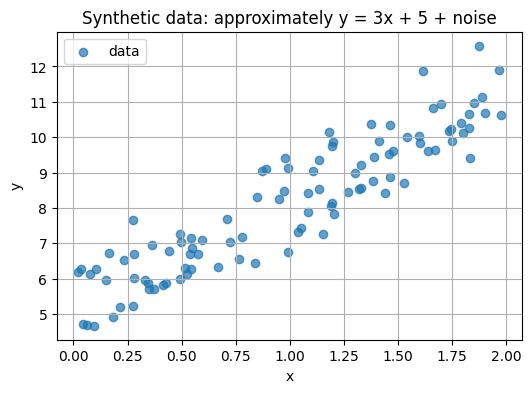

In [ ]:

# Generate a simple 1D synthetic dataset: y = 3x + 5 + noise
n = 100
X = 2 * np.random.rand(n, 1)  # feature in [0, 2)
theta0_true = 5.0
theta1_true = 3.0
y_true = theta1_true * X[:, 0] + theta0_true
noise = np.random.randn(n) * 0.8
y = y_true + noise

# Visualize
plt.scatter(X[:, 0], y, alpha=0.7, label="data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic data: approximately y = 3x + 5 + noise")
plt.legend()
plt.show()



### What this code does, line by line

- `n = 100` — choose sample size.
- `X = 2 * np.random.rand(n, 1)` — draw `n` scalar features uniformly in `[0,2)`; shape `(n,1)` keeps the feature as a 2D array.
- `y_true = 3.0 * X[:, 0] + 5.0` — construct the noiseless linear signal with slope `3` and intercept `5`, using the x coordinates (in column `0`) of all rows of `X`
- `noise = np.random.randn(n) * 0.8` — Gaussian noise with standard deviation `0.8`.
- `y = y_true + noise` — observed targets.
- Plotting:
  - `plt.scatter(...)` — show `(x, y)` pairs.
  - Axis labels and title document the generative process.
  - `plt.legend(); plt.show()` — finalize the figure.

#### Mathematical step
We assume a data-generating model `y = θ₀ + θ₁ x + ε` with `ε ~ N(0, σ²)`. Here, `θ₀ = 5`, `θ₁ = 3`, and `σ ≈ 0.8`.



## 2. Loss Function (Mean Squared Error)

Given predictions $ \hat{y}_i = \theta_0 + \theta_1 x_i $, the **Mean Squared Error (MSE)** is

$$ J(\theta_0, \theta_1) = \frac{1}{n} \sum_{i=1}^n \big(\hat{y}_i - y_i\big)^2. $$

Minimizing MSE yields the **Ordinary Least Squares (OLS)** solution.


In [ ]:

def mse(theta0, theta1, X, y):
    y_hat = theta0 + theta1 * X[:, 0]
    return np.mean((y_hat - y)**2)

print("MSE at theta0=0, theta1=0:", mse(0, 0, X, y))


MSE at theta0=0, theta1=0: 68.08372731406253



### What this code does, line by line

- Define `mse(theta0, theta1, X, y)`:
  - `y_hat = theta0 + theta1 * X[:, 0]` — compute predictions for each scalar input `x`.
  - `return np.mean((y_hat - y)**2)` — average squared error (MSE).
- `print("MSE at theta0=0, theta1=0:", ...)` — evaluate the loss at the origin.

#### Mathematical step
The objective is $ J(θ₀, θ₁) = \frac{1}{n} \sum_i (θ₀ + θ₁ x_i - y_i)^2 $. Minimizing `J` yields the OLS solution.


## 3. Closed-Form Solution

Here, we estimate $\theta$ parameters that model an equation to fit a line to the data.

### 3.1. **Goal**:  

   We want to find the parameter vector  
   $$
   \boldsymbol{\theta} =
   \begin{bmatrix}
   \theta_0 \\ \theta_1 \\ \vdots \\ \theta_d
   \end{bmatrix}
   $$
   that minimizes the **Mean Squared Error (MSE)** cost function:
   $$
   J(\boldsymbol{\theta}) = \frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i)^2 = \frac{1}{n}\| X\boldsymbol{\theta} - \mathbf{y} \|_2^2.
   $$
   Here:
   - $ X $ is the **design matrix** of shape $(n, d+1)$ containing one row per observation.  
     The first column of $ X $ is a column of ones (to represent the intercept term).
   - $ \mathbf{y} $ is the column vector of targets.
   - $ \hat{y} = X \boldsymbol{\theta} $ are the model predictions.

### 3.2 **Create an Augmented Design Matrix $ X $ with a leading column vector $ [ 1, ..., 1 ]^\top $ for the Intercept**:

In simple linear regression, we write the model as

$$
\hat{y}_i = \theta_0 + \theta_1 x_{i1} + \theta_2 x_{i2} + \dots + \theta_d x_{id}.
$$

Here, $\theta_0$ is the **intercept**, and $\theta_1, \dots, \theta_d$ are the coefficients for the features.  
To express this model compactly in matrix form, we define a **design matrix** $X$ that includes a column of ones as its first column:

$$
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \dots & x_{1d} \\\\
1 & x_{21} & x_{22} & \dots & x_{2d} \\\\
\vdots & \vdots & \vdots & \ddots & \vdots \\\\
1 & x_{n1} & x_{n2} & \dots & x_{nd}
\end{bmatrix}.
$$

Then the model can be written compactly as:

$$
\hat{\mathbf{y}} = X \boldsymbol{\theta},
$$

where

$$
\boldsymbol{\theta} =
\begin{bmatrix}
\theta_0 \\\\
\theta_1 \\\\
\vdots \\\\
\theta_d
\end{bmatrix}.
$$

---

#### 3.2.1 Effect of the Augmented Design Matrix

This augmentation converts the affine model $\hat{y} = \theta_0 + X\boldsymbol{\theta}_{1:}$ into a purely linear form $\hat{y} = X'\boldsymbol{\theta}$.  It ensures that the normal equation captures both slope and intercept in a single vector, and it gives the model the flexibility to shift vertically, not just rotate or scale.

In other words, the un-augmented matrix `x[:, 0]` models the x coordinate slope, and the augmented matrix `[1 | x[:, 0]` models the y-intercept as well as the x coordinate slope.

1. **Unified Matrix Formulation:**  
   By adding a leading column of ones, the intercept term $\theta_0$ becomes part of the vector $\boldsymbol{\theta}$, allowing the entire model to be expressed as a single matrix multiplication.  
   Without this column, we would have to treat the intercept separately as  
   $$\hat{\mathbf{y}} = X\boldsymbol{\theta} + \theta_0 \mathbf{1},$$  
   which breaks the clean symmetry of the normal equation.

2. **Normal Equation Compatibility:**  
   The closed-form solution  
   $$
   \boldsymbol{\theta}^* = (X^\top X)^{-1} X^\top \mathbf{y}
   $$  
   implicitly assumes that $X$ already includes this column of ones.  
   Without it, the intercept term would not be estimated as part of the vector $\boldsymbol{\theta}$.

3. **Geometric Interpretation:**  
   The column of ones corresponds to a **basis vector for constant offsets**—it allows the regression hyperplane to shift up or down to best fit the data, rather than being forced to pass through the origin.  
   - Without the intercept column, the model would be constrained so that $\hat{y} = 0$ when all features are zero.
   - Including it lets the plane (or line) freely translate in the response direction, providing a better fit when the true relationship does not pass through the origin.

4. **Statistical Interpretation:**  
   The intercept $\theta_0$ represents the **expected value of $y$ when all predictors are zero** (after any standardization or centering).  
   Including the column of ones ensures this constant baseline is learned directly from the data.

### 3.3. **Expand the cost function**:  
   Writing it in vector form:
   $$
   J(\boldsymbol{\theta}) = \frac{1}{n}(X\boldsymbol{\theta} - \mathbf{y})^\top (X\boldsymbol{\theta} - \mathbf{y}).
   $$
   Expanding this quadratic form:
   $$
   J(\boldsymbol{\theta}) = \frac{1}{n} \left(
       \boldsymbol{\theta}^\top X^\top X \boldsymbol{\theta}
       - 2 \mathbf{y}^\top X \boldsymbol{\theta}
       + \mathbf{y}^\top \mathbf{y}
   \right).
   $$

### 3.4. **Differentiate with respect to $ \boldsymbol{\theta} $**:  

Here, we take the derivative of the error function $J$ with respect to $\theta$ so that we can minimize it.

---

#### 3.4.1. Start with the cost function

We define the MSE objective:

$$
J(\boldsymbol{\theta}) = \frac{1}{n} (X\boldsymbol{\theta} - \mathbf{y})^\top (X\boldsymbol{\theta} - \mathbf{y})
$$

Here:
- $X$ is an $n \times d$ design matrix,
- $\boldsymbol{\theta}$ is a $d \times 1$ parameter vector,
- $\mathbf{y}$ is an $n \times 1$ target vector,
- $(X\boldsymbol{\theta} - \mathbf{y})$ is the vector of residuals.

---

#### 3.4.2. Expand the expression

Multiply out the quadratic form:

$$
J(\boldsymbol{\theta}) = \frac{1}{n}
\left(
\boldsymbol{\theta}^\top X^\top X \boldsymbol{\theta}
- 2 \mathbf{y}^\top X \boldsymbol{\theta}
+ \mathbf{y}^\top \mathbf{y}
\right)
$$

The last term $\mathbf{y}^\top \mathbf{y}$ is constant with respect to $\boldsymbol{\theta}$ and drops out when differentiating.

---

#### 3.4.3. Use standard results from matrix calculus

1. $\displaystyle \frac{\partial}{\partial \boldsymbol{\theta}} (\boldsymbol{\theta}^\top A \boldsymbol{\theta}) = (A + A^\top)\boldsymbol{\theta}$
2. $\displaystyle \frac{\partial}{\partial \boldsymbol{\theta}} (\mathbf{b}^\top \boldsymbol{\theta}) = \mathbf{b}$

Since $A = X^\top X$ is symmetric, $(A + A^\top) = 2A$.

Therefore, the derivative of the first term of the equation is:

$$
\frac{\partial}{\partial \boldsymbol{\theta}} \big[ \boldsymbol{\theta}^\top X^\top X \boldsymbol{\theta} \big]
= 2X^\top X \boldsymbol{\theta}
$$

and the derivative of the term equation is:

$$
\frac{\partial}{\partial \boldsymbol{\theta}} \big[ -2\mathbf{y}^\top X \boldsymbol{\theta} \big]
= -2X^\top \mathbf{y}.
$$

and the derivative of $\mathbf{y}^\top \mathbf{y}$ is $0$ with respect to $\theta$, since it is a constant with respect to $\theta$.

---

#### 3.4.4. Combine the results

$$
\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})
= \frac{1}{n} (2X^\top X \boldsymbol{\theta} - 2X^\top \mathbf{y})
$$

Simplify:

$$
\boxed{
\frac{\partial J}{\partial \boldsymbol{\theta}} = \frac{2}{n} X^\top (X\boldsymbol{\theta} - \mathbf{y})
}
$$

---

#### 3.4.5. Therefore, $\frac{\partial J}{\partial \boldsymbol{\theta}} = \frac{2}{n} X^\top (X\boldsymbol{\theta} - \mathbf{y})$

   $$
   \frac{\partial J}{\partial \boldsymbol{\theta}} = \frac{2}{n} X^\top (X\boldsymbol{\theta} - \mathbf{y}).
   $$

This equation expresses the **gradient of the Mean Squared Error (MSE)** cost function in **matrix form**, derived using results from matrix calculus.

### 3.5. **Set the gradient to zero** (first-order condition for a minimum):
   $$
   X^\top (X\boldsymbol{\theta} - \mathbf{y}) = 0.
   $$

   Note that $\frac{2}{n}$ drops out as they are constant.

### 3.6. **Solve for $ \boldsymbol{\theta} $**:
   $$
   X^\top X \boldsymbol{\theta} = X^\top \mathbf{y}.
   $$

   Provided $ X^\top X $ is invertible (i.e., $ X $ has full column rank, such that the columns of $ X $ are linearly independent),
   we can multiply both sides by $ (X^\top X)^{-1} $ to obtain the closed-form solution:
   $$
   \boxed{
   \boldsymbol{\theta}^* = (X^\top X)^{-1} X^\top \mathbf{y}.
   }
   $$

---

### 3.6.1. Interpretation:
   
  - **$X^\top X$ (the Gram matrix):**  
    This matrix encodes the pairwise correlations (inner products) among the columns of $X$, and captures correlations among features.  
    - The diagonal entries represent the sum of squares of each feature (their magnitudes).  
    - The off-diagonal entries quantify how strongly two features are linearly related (their covariances).  
    - When $X$ has *full column rank*, $X^\top X$ is invertible, which means the features define unique, linearly independent directions in feature space.  
    - If the columns are linearly dependent, $X^\top X$ becomes singular, and the least-squares solution is not unique.

  - **$X^\top \mathbf{y}$ (feature–target covariance vector):**  
    This vector measures how each feature covaries with the response variable $\mathbf{y}$.  
    - Each component $x_j^\top y$ reflects how changes in feature $x_j$ align with changes in the target.  
    - In essence, it quantifies how predictive each feature is with respect to $\mathbf{y}$.

  - **$(X^\top X)^{-1} X^\top$ (the pseudoinverse of $X$):**  
    This product acts as a **projection operator** that maps $\mathbf{y}$ onto the subspace spanned by the columns of $X$.  
    - The fitted values $\hat{\mathbf{y}} = X(X^\top X)^{-1} X^\top \mathbf{y}$ are the **orthogonal projection** of $\mathbf{y}$ onto this subspace.  
    - Geometrically, this means linear regression finds the point $\hat{\mathbf{y}}$ in the column space of $X$ that lies closest to $\mathbf{y}$ in the Euclidean sense.  
    - The residual vector $(\mathbf{y} - \hat{\mathbf{y}})$ is orthogonal to every column of $X$, ensuring that model errors are uncorrelated with all predictors.

  - **Intuitive summary:**  
    Linear regression computes coefficients $\boldsymbol{\theta}$ so that predictions $X\boldsymbol{\theta}$ form the orthogonal projection of $\mathbf{y}$ onto the feature subspace defined by $X$.  
    The term $X^\top X$ corrects for inter-feature correlations, while $X^\top \mathbf{y}$ captures the alignment between features and the target.  
    Together, the expression $(X^\top X)^{-1} X^\top \mathbf{y}$ yields the parameter vector that produces the closest possible linear approximation to $\mathbf{y}$ within that subspace.

### 3.7. **Closed Form Matrix Solution**:

For linear regression with an intercept, the OLS solution can be written as

$$ \boldsymbol{\theta}^* = (X^\top X)^{-1} X^\top \mathbf{y}, $$

where $ X $ has a leading column of ones for the intercept.

Closed-form solution: theta0=5.201, theta1=2.967
Estimated model equation: y = 2.967 x + 5.201
True equation: y = 3.000 x + 5.000


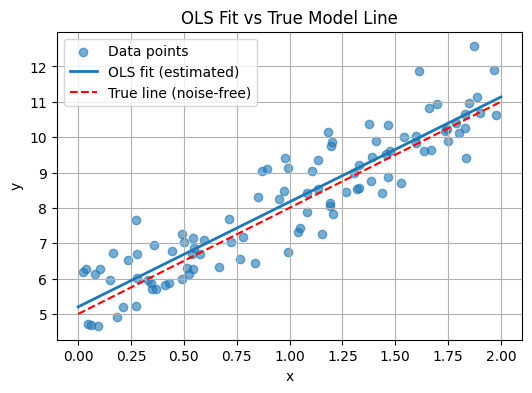

MSE (closed form): 0.5496195375098232


In [ ]:

# Build design matrix with intercept
X_design = np.c_[np.ones((n, 1)), X]  # [1, x]
theta_star = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ y)

theta0_star, theta1_star = theta_star
print(f"Closed-form solution: theta0={theta0_star:.3f}, theta1={theta1_star:.3f}")
print(f"Estimated model equation: y = {theta1_star:.3f} x + {theta0_star:.3f}")
print(f"True equation: y = {theta1_true:.3f} x + {theta0_true:.3f}")

# Plot fitted line and true line
x_line = np.linspace(0, 2, 100)
y_line_fit = theta0_star + theta1_star * x_line
y_line_true = theta0_true + theta1_true * x_line

plt.scatter(X[:, 0], y, alpha=0.6, label="Data points")
plt.plot(x_line, y_line_fit, label="OLS fit (estimated)", linewidth=2)
plt.plot(x_line, y_line_true, label="True line (noise-free)", linestyle="--", color="red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("OLS Fit vs True Model Line")
plt.legend()
plt.show()

print("MSE (closed form):", mean_squared_error(y, theta0_star + theta1_star * X[:,0]))



### What this code does, line by line

- `X_design = np.c_[np.ones((n, 1)), X]` — build the design matrix `X̃` by concatenating a column of ones (intercept) with `X`.
- `theta_star` = $ ( \tilde{X}^\top \tilde{X} )^{-1} \tilde{X}^\top \mathbf{y} $ — closed-form OLS using the normal equation.
- Unpack and print `θ₀`, `θ₁` with three-decimal formatting.
- Create a dense `x_line` grid and compute `y_line = θ₀ + θ₁ x_line` for plotting the fitted line.
- Scatter the data and overlay the OLS fit.
- Compute and print the MSE of the fitted model on the observed `X`.

#### Mathematical step
The normal equation solves $ \arg\min_θ \|X̃θ - y\|_2^2 $. When `X̃ᵀX̃` is invertible, $\boldsymbol{\theta}^* = ( \tilde{X}^\top \tilde{X} )^{-1} \tilde{X}^\top \mathbf{y}$.



## 4. Optimization by Gradient Descent

The normal equation we derived earlier provides an exact solution but is **computationally expensive** for large feature sets ($ O(d^3) $ due to matrix inversion).  However, in practice, iterative methods (like gradient descent or stochastic gradient descent) are used for high-dimensional data.

The gradient of the MSE w.r.t. parameters $ \theta_0, \theta_1 $ is:

$$ \nabla J = \frac{2}{n} \sum_{i=1}^n \begin{bmatrix} (\hat{y}_i - y_i) \\ (\hat{y}_i - y_i) x_i \end{bmatrix}. $$

The gradient gives us the direction of the error function, or the slope of the error function, which we can follow downward toward its minimum value.  With multidimensional data, the gradients can move in many different directions across these dimensions, so we take a small step toward the minimum value to avoid moving toward a local minimum.  As a result, we iteratively compute the gradient and subtract small amounts (scaled by a **learning rate** hyperparameter $\alpha$) from the $\theta$ parameters:

$$ \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \alpha \nabla J, $$

Larger values of the learning rate $\alpha$ lead to larger steps toward this minimum mean-squared error (also called **loss**), requiring fewer iterations, but risking stepping over the global minimum.

GD solution: theta0=5.199, theta1=2.970


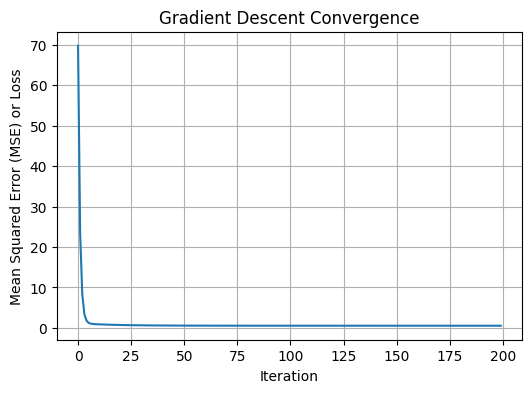

In [ ]:

def gradient_descent(X, y, lr=0.1, steps=200):
    theta0, theta1 = 0.0, 0.0
    history = []
    for t in range(steps):
        y_hat = theta0 + theta1 * X[:, 0]
        err = y_hat - y
        grad0 = (2/len(X)) * np.sum(err)
        grad1 = (2/len(X)) * np.sum(err * X[:, 0])
        theta0 -= lr * grad0
        theta1 -= lr * grad1
        history.append((theta0, theta1, np.mean(err**2)))
    return theta0, theta1, np.array(history)

theta0_gd, theta1_gd, hist = gradient_descent(X, y, lr=0.1, steps=200)

print(f"GD solution: theta0={theta0_gd:.3f}, theta1={theta1_gd:.3f}")
plt.plot(hist[:,2])
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (MSE) or Loss")
plt.title("Gradient Descent Convergence")
plt.show()



### What this code does, line by line

- Define `gradient_descent(X, y, lr, steps)`:
  - Initialize `θ₀, θ₁ = 0`.
  - Loop for `steps` iterations:
    - `y_hat = θ₀ + θ₁ x` and `err = y_hat - y` — residuals.
    - `grad0 = (2/n) * sum(err)` — derivative of MSE wrt `θ₀`.
    - `grad1 = (2/n) * sum(err * x)` — derivative wrt `θ₁`.
    - Parameter update: `θ ← θ - α ∇J` using learning rate `lr`.
    - Record `(θ₀, θ₁, current MSE)` in `history` for plotting.
  - Return final `θ` and the history array.
- Call GD with `lr=0.1`, `steps=200`, then print the solution.
- Plot `hist[:,2]` — the MSE trajectory versus iteration.

#### Mathematical step
For $ J(θ)=\frac{1}{n}\sum (θ₀+θ₁ x_i - y_i)^2 $, and $\hat y_i = θ₀+θ₁ x_i $

$ \partial J/\partial θ₀ = \tfrac{2}{n} \sum (\hat y_i - y_i) $,  

$ \partial J/\partial θ₁ = \tfrac{2}{n} \sum (\hat y_i - y_i) x_i $.

**Derivation:**

Given: For $J(\theta)=\frac{1}{n}\sum_{i=1}^n (\theta_0+\theta_1 x_i - y_i)^2$, and $\hat y_i = \theta_0+\theta_1 x_i$.

We can write the residual as $r_i := \hat y_i - y_i = \theta_0 + \theta_1 x_i - y_i$, so
$$
J(\theta) \;=\; \frac{1}{n}\sum_{i=1}^n r_i^2.
$$

**Recall** by the chain rule $\frac{\partial J}{\partial \theta_i} = \frac{\partial J}{\partial r} \cdot \frac{\partial r}{\partial \theta_i}$

**Derivative w.r.t. $\theta_0$** (chain rule; $\partial r_i/\partial \theta_0 = 1$):
$$
\frac{\partial J}{\partial \theta_0}
= \frac{1}{n}\sum_{i=1}^n 2\,r_i \cdot \frac{\partial r_i}{\partial \theta_0}
= \frac{2}{n}\sum_{i=1}^n r_i
= \frac{2}{n}\sum_{i=1}^n (\hat y_i - y_i).
$$

**Derivative w.r.t. $\theta_1$** (chain rule; $\partial r_i/\partial \theta_1 = x_i$):
$$
\frac{\partial J}{\partial \theta_1}
= \frac{1}{n}\sum_{i=1}^n 2\,r_i \cdot \frac{\partial r_i}{\partial \theta_1}
= \frac{2}{n}\sum_{i=1}^n r_i\,x_i
= \frac{2}{n}\sum_{i=1}^n (\hat y_i - y_i)\,x_i.
$$

Therefore,
$$
\frac{\partial J}{\partial \theta_0} = \tfrac{2}{n} \sum_{i=1}^n (\hat y_i - y_i),
\qquad
\frac{\partial J}{\partial \theta_1} = \tfrac{2}{n} \sum_{i=1}^n (\hat y_i - y_i)\,x_i.
$$

**Stacked gradient form**:
$$
\nabla J(\theta) \;=\;
\begin{bmatrix}
\frac{\partial J}{\partial \theta_0}\\[2pt]
\frac{\partial J}{\partial \theta_1}
\end{bmatrix}
= \frac{2}{n} \sum_{i=1}^n
\begin{bmatrix}
(\hat y_i - y_i)\\[2pt]
(\hat y_i - y_i)\,x_i
\end{bmatrix}.
$$




## 5. Feature Scaling & Multiple Linear Regression

Gradient methods benefit from **feature scaling**. We also extend to multiple features (e.g., polynomial features).


Test RMSE: 0.7404818588934641
Test R^2: 0.8507986374795194


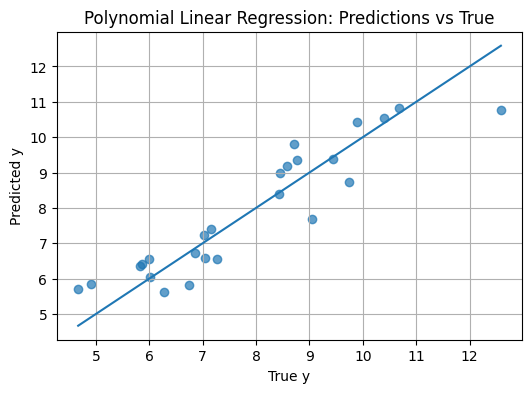

In [ ]:

# Build polynomial features up to degree 3
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)  # [x, x^2, x^3]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.25, random_state=42)

# Pipeline: Standardize -> Linear Regression
model = Pipeline([
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Test RMSE:", math.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R^2:", r2_score(y_test, y_pred))

# Plot predictions against ground truth on test set
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Polynomial Linear Regression: Predictions vs True")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])  # y=x line
plt.show()



### What this code does, line by line

- `PolynomialFeatures(degree=3, include_bias=False)` — create `[x, x², x³]` features (no extra bias term; the regressor adds intercept).
- `X_poly = poly.fit_transform(X)` — expand the single feature into polynomial features.
- `train_test_split(...)` — hold out 25% of examples for testing (random_state for reproducibility).
- `Pipeline([("scaler", StandardScaler()), ("linreg", LinearRegression())])` — standardize features, then fit OLS.  `StandardScaler` normalizes the data to a mean of `0` and standard deviation of `1`, so that the units don't matter.  It does this by calculating `x = (x - np.mean(x)) / np.std(x)`.
- `model.fit(X_train, y_train)` — estimate coefficients across the pipeline (first the `StandardScaler`, then the `LinearRegression` model).
- `y_pred = model.predict(X_test)` — generate predictions.
- Report `RMSE` and `R²` to summarize generalization.
- Plot a scatter of `True y` vs `Predicted y` and overlay the `y=x` reference line.

#### Mathematical step
Polynomial regression is still linear-in-parameters: $ \hat y = θ₀ + θ₁ x + θ₂ x^2 + θ_3 x^3 $. OLS solves for $ θ $ in the expanded feature space.  Thus, we can use linear regression to model non-linear relationships in our data.

---

### Summarizing Model Generalization with RMSE and \$R^2\$

We evaluated the polynomial regression model using two key metrics:

```python
print("Test RMSE:", math.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R^2:", r2_score(y_test, y_pred))
```

Here, `y_test` are the true target values, and `y_pred` are the predictions from the model.

---

#### Root Mean Squared Error (RMSE)

**Definition:**

The Root Mean Squared Error measures the *average magnitude of prediction error* in the same units as the target variable:

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i)^2}
$$

**Interpretation:**
- RMSE tells you how far off, on average, your predictions are from the true values.
- Squaring the errors penalizes large deviations more heavily than small ones.
- Taking the square root converts the result back into the same units as the target variable.

**Why it's useful:**
- RMSE is directly interpretable in the context of the dependent variable.
- It is sensitive to outliers, making it a good general measure of prediction accuracy.
- In this notebook, if the noise added to the synthetic data has a standard deviation of about 0.8, a well-fitted model should achieve RMSE ≈ 0.8 on the test data.

---

#### Coefficient of Determination (\$R^2\$)

**Definition:**

The \$R^2\$ score measures the *proportion of variance in the target variable explained by the model*:

$$
R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}
$$

where \$\bar{y}\$ is the mean of the true \$y\$ values.

**Interpretation:**
- The numerator (\$\sum (y_i - \hat{y}_i)^2\$) is the *residual sum of squares* — the unexplained variation.
- The denominator (\$\sum (y_i - \bar{y})^2\$) is the *total sum of squares* — total variation in the data.
- \$R^2\$ represents the fraction of variance in \$y\$ that is captured by the model.

| \$R^2\$ value | Interpretation |
|---------------|----------------|
| 1.0 | Perfect fit — predictions exactly match the data |
| 0.9 | Model explains 90% of the variance |
| 0 | Model no better than predicting the mean of \$y\$ |
| < 0 | Model performs worse than a constant mean predictor |

**Statistical relationship:**
- For simple linear regression, $R^2$ equals the square of the correlation between true and predicted values:
  $$
  R^2 = (\text{corr}(y, \hat{y}))^2
  $$

---

#### Relationship Between RMSE and \$R^2\$

- **RMSE** provides an *absolute* measure of model error — “on average, how far off are we?”
- **\$R^2\$** provides a *relative* measure — “how much better is the model than a naive mean predictor?”

For a perfect model, RMSE → 0 and \$R^2 → 1$.
If the model merely predicts the mean of \$y\$, RMSE ≈ standard deviation of \$y\$ and \$R^2 = 0\$.

---

#### In this Example

Our true model is \$y = 3x + 5 + \epsilon\$ with noise \$\epsilon \sim N(0, 0.8^2)\$.
Thus, for a well-fitted model:

- **RMSE** should be close to the noise level, around 0.8.
- **\$R^2\$** should be high (≈ 0.98 or above), indicating that the model explains nearly all variance in \$y\$.

---

#### Summary

| Metric | Formula | Scale | Interpretation |
|---------|----------|--------|----------------|
| RMSE | \$\sqrt{\frac{1}{n} \sum (\hat{y}_i - y_i)^2}\$ | Same units as \$y\$ | Average magnitude of prediction error |
| \$R^2\$ | \$1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}\$ | Unitless (≤ 1) | Proportion of variance in \$y\$ explained by the model |

Think of RMSE and \$R^2\$ as two complementary perspectives:

- **RMSE:** "How far are our predictions from reality, on average?"
- **\$R^2\$:** "How much of the variation in the data are we actually explaining?"

Together, they provide both **quantitative** (RMSE) and **qualitative** (\$R^2\$) measures of model performance.



## 6. Regularization: Ridge and Lasso

### Overfitting

**Overfitting** occurs when a model learns not only the true underlying pattern in the data but also the random noise specific to the training set.  As a result, the model performs **extremely well on the training data** but **poorly on unseen (test) data**.

Mathematically, overfitting arises when the model is too **complex** relative to the amount of data or the inherent signal in the data.  
In the context of polynomial regression, this often happens when we use **too many polynomial terms**:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \dots + \theta_d x^d.
$$

As the degree $d$ increases, the model gains flexibility to fit the training data almost perfectly — even to the noise — which results in **high variance** and poor generalization.

---

### Regularization: Controlling Model Complexity

**Regularization** is a technique to prevent overfitting by penalizing large coefficient values in the regression model.

The idea is to modify the loss function (Mean Squared Error) by adding a **penalty term** that grows with the magnitude of the coefficients:

$$
J(\boldsymbol{\theta}) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda P(\boldsymbol{\theta}),
$$

where $\lambda \ge 0$ controls the strength of the penalty, and $P(\boldsymbol{\theta})$ defines the type of regularization.

---

### Ridge Regression (L2 Regularization)

**Ridge regression** adds an L2 penalty term on the coefficients:

$$
P(\boldsymbol{\theta}) = \|\boldsymbol{\theta}\|_2^2 = \sum_{j=1}^d \theta_j^2.
$$

The resulting objective function is:

$$
J_{\text{ridge}}(\boldsymbol{\theta}) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^d \theta_j^2.
$$

**Key properties of Ridge:**
- Penalizes large coefficients but never sets them exactly to zero.  
- Shrinks all coefficients toward zero, reducing variance but keeping all features in the model.  
- Particularly useful when many features are correlated (multicollinearity), as it stabilizes the solution.

---

### Lasso Regression (L1 Regularization)

**Lasso regression** adds an L1 penalty term:

$$
P(\boldsymbol{\theta}) = \|\boldsymbol{\theta}\|_1 = \sum_{j=1}^d |\theta_j|.
$$

The resulting objective function is:

$$
J_{\text{lasso}}(\boldsymbol{\theta}) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^d |\theta_j|.
$$

**Key properties of Lasso:**
- Encourages *sparsity*: some coefficients become exactly zero when $\lambda$ is large enough.  
- Performs both **regularization** and **feature selection**, effectively removing irrelevant predictors from the model.  
- Useful when you suspect that only a subset of features are truly informative.

---

### Comparing Ridge and Lasso

| Property | Ridge (L2) | Lasso (L1) |
|-----------|-------------|-------------|
| Penalty term | $\sum \theta_j^2$ | $\sum |\theta_j|$ |
| Coefficients | Shrunk continuously toward zero | Some driven exactly to zero |
| Feature selection | No | Yes (implicit) |
| Handles multicollinearity | Very well | Less stable when features are highly correlated |
| Optimization surface | Circular contours (smooth) | Diamond-shaped contours (sharp corners promote sparsity) |

---

### Choosing Between Them

- **Ridge** is preferred when:
  - All predictors contribute to the outcome.
  - The goal is to stabilize coefficients without eliminating features.
  - Features are highly correlated.

- **Lasso** is preferred when:
  - You expect only a few features to be truly important.
  - You want an interpretable, sparse model that performs implicit feature selection.

---

### Summary

- Overfitting occurs when a model is too complex and learns noise rather than signal.
- Regularization combats overfitting by adding a penalty to large coefficients.
- **Ridge** (L2) shrinks coefficients smoothly.
- **Lasso** (L1) can shrink some coefficients exactly to zero.
- The regularization strength $\lambda$ balances bias and variance:
  - Small $\lambda$ → less penalty, possible overfitting.
  - Large $\lambda$ → more penalty, possible underfitting.

To mitigate overfitting, we add penalties:

- **Ridge (L2)** adds $ \lambda \|\boldsymbol{\theta}\|_2^2 $.
- **Lasso (L1)** adds $ \lambda \|\boldsymbol{\theta}\|_1 $ and can drive coefficients to zero.

Here, both Ridge and Lasso were applied to show how **increasing $\lambda$ reduces test error up to a point**, after which too much regularization harms performance — demonstrating the fundamental **bias–variance tradeoff**.



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.042e+01, tolerance: 2.539e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

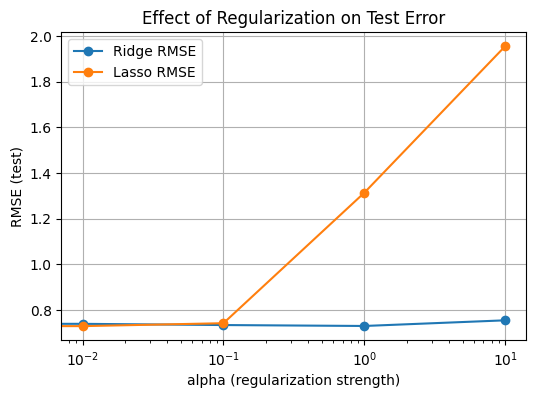

In [ ]:

alphas = [0.0, 0.01, 0.1, 1.0, 10.0]
rmse_ridge = []
rmse_lasso = []

for a in alphas:
    ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=a))])
    ridge.fit(X_train, y_train)
    ypr = ridge.predict(X_test)
    rmse_ridge.append(math.sqrt(mean_squared_error(y_test, ypr)))

    lasso = Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=a, max_iter=10000))])
    lasso.fit(X_train, y_train)
    ypl = lasso.predict(X_test)
    rmse_lasso.append(math.sqrt(mean_squared_error(y_test, ypl)))

plt.plot(alphas, rmse_ridge, marker="o", label="Ridge RMSE")
plt.plot(alphas, rmse_lasso, marker="o", label="Lasso RMSE")
plt.xscale("log")
plt.xlabel("alpha (regularization strength)")
plt.ylabel("RMSE (test)")
plt.title("Effect of Regularization on Test Error")
plt.legend()
plt.show()



### What this code does, line by line

- Sweep `alphas = [0, 0.01, 0.1, 1, 10]` to observe regularization effects.
- For each `a`:
  - **Ridge** pipeline: standardize → `Ridge(alpha=a)`; compute test RMSE and collect.
  - **Lasso** pipeline: standardize → `Lasso(alpha=a, max_iter=10000)`; compute test RMSE and collect.
- Plot RMSE vs `alpha` on a log-x scale for both methods.

#### Mathematical step
Ridge minimizes $ \|Xθ - y\|_2^2 + \lambda \|θ\|_2^2 $.

Lasso minimizes $ \|Xθ - y\|_2^2 + \lambda \|θ\|_1 $, encouraging sparsity in coefficients.

---


### Why RMSE Increased More with Lasso than with Ridge

Both Ridge and Lasso regularization modify the least-squares objective to penalize large coefficients:

- **Ridge (L2):**

  $$
  J_{\text{ridge}}(\boldsymbol{\theta}) =
  \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^d \theta_j^2
  $$

- **Lasso (L1):**

  $$
  J_{\text{lasso}}(\boldsymbol{\theta}) =
  \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^d |\theta_j|
  $$

Both introduce bias (pulling coefficients toward zero) in exchange for reduced variance, which helps prevent overfitting.  
However, they differ in *how* they shrink the coefficients.

---

#### Ridge Shrinks Smoothly, Lasso Shrinks Abruptly

- **Ridge (L2)** applies a *quadratic* penalty.  
  The gradient of the penalty increases gradually as coefficients grow, so each parameter is scaled down continuously.

- **Lasso (L1)** applies an *absolute value* penalty.  
  The gradient is constant in magnitude but changes sign at zero — producing a “kink” in the loss surface.  
  This shape encourages some coefficients to become **exactly zero** once the penalty exceeds a certain threshold.

---

#### In Your Example: Few Features, All Relevant

In Step 6, your model used **polynomial features of a single variable ($x, x^2, x^3$)** — and **all of them actually carry useful information** for fitting the true relationship $y = 3x + 5 + \epsilon$.

When you apply **Lasso**:
- It can *zero out* one or more of those features entirely, even though they're genuinely helpful.
- This under-representation of important terms leads to **higher bias** — the model becomes too simple.

When you apply **Ridge**:
- It merely *shrinks* the coefficients (keeps them all nonzero), so it maintains the general shape of the relationship.
- The bias increases more gently, and the model retains more predictive power.

Result:
> As $\lambda$ (or $\alpha$) grows, Lasso degrades faster because it discards useful predictors, while Ridge just dampens them.

---

#### Geometric Explanation

Imagine the contours of the MSE loss function (elliptical) and the constraint region imposed by regularization:

- Ridge's L2 constraint is **circular**:  
  It favors small but nonzero coefficients.
- Lasso's L1 constraint is **diamond-shaped** with **sharp corners** at the axes:  
  The optimum often hits a corner — meaning one or more coefficients become exactly zero.

Because Lasso's feasible region has corners, it “snaps” coefficients to zero sooner, introducing abrupt changes in the model and larger predictive errors when features are genuinely needed.

---

#### Statistical Perspective: Bias–Variance Tradeoff

| Method | Effect on Variance | Effect on Bias | RMSE Behavior |
|---------|-------------------|----------------|----------------|
| **Ridge** | Decreases variance smoothly | Increases bias slightly | RMSE rises slowly with $\lambda$ |
| **Lasso** | Can over-shrink (zero out terms) | Bias increases sharply | RMSE rises faster with $\lambda$ |

Lasso's sparsity property is beneficial when many features are **irrelevant**, but in your case, all features help.  
Thus, it **underfits** faster than Ridge as regularization increases.

---

#### Summary

- Ridge keeps all features, merely shrinking their influence → *gentle* RMSE increase.  
- Lasso can eliminate relevant features → *steeper* RMSE increase.  
- In problems where most features matter, **Ridge** typically performs better.
- In high-dimensional, sparse problems (many irrelevant features), **Lasso** can outperform Ridge.

**In this example:**  
Since every polynomial term contributes to the true signal, Lasso's sparsity hurts predictive accuracy more than it helps — hence the higher RMSE.



## 7. Diagnostics: Residuals

A useful diagnostic is the **residual plot** (errors vs. predictions). Ideally, residuals are roughly zero-mean and display no clear pattern.


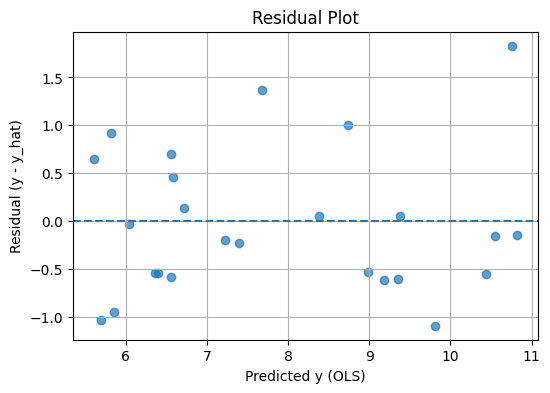

In [ ]:

ols = LinearRegression().fit(X_train, y_train) # ordinary least squares
y_pred_ols = ols.predict(X_test)
residuals = y_test - y_pred_ols

plt.scatter(y_pred_ols, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted y (OLS)")
plt.ylabel("Residual (y - y_hat)")
plt.title("Residual Plot")
plt.show()



### What this code does, line by line

- Fit a plain `LinearRegression` on the training set.
- Compute predictions `y_pred_ols` on the test set.
- `residuals = y_test - y_hat` — signed errors.
- Scatter `y_hat` (x-axis) vs residuals (y-axis); add a horizontal 0-line to inspect patterns.

#### Diagnostic step
Randomly-scattered residuals around zero suggest model adequacy; systematic curvature, funnel shapes, or heteroscedasticity suggest misspecification or non-constant variance.



### Exercises

1. **Learning rate exploration:** Modify the learning rate in the gradient descent cell (e.g., `lr=0.001`, `lr=1.0`). What happens to convergence?
2. **Polynomial degree:** Change `PolynomialFeatures(degree=3)` to other degrees (e.g., 2, 5, 10). Plot training and test errors to observe under/overfitting.
3. **Heteroscedasticity:** Modify the data generation to make noise grow with `x`. How does the residual plot change?
4. **Feature scaling:** Remove `StandardScaler` from the pipeline and use `SGDRegressor`. Does training stability change?



---
# Part II — Logistic Regression

## 8. From Regression to Classification

When the target is **categorical** (e.g., spam vs. not-spam), linear regression is inappropriate. Logistic regression models the **probability** of a class via the **sigmoid**:

$$ \sigma(z) = \frac{1}{1 + e^{-z}}, \quad p(y=1\mid \mathbf{x}) = \sigma(\mathbf{x}^\top \boldsymbol{\theta}). $$

We fit parameters by **maximizing the (log-)likelihood**, equivalently minimizing the loss.  Here, we define loss as the **cross-entropy**, which commonly used in **classification problems**, particularly in **logistic regression** and **neural networks**.  It measures the difference between two probability distributions — the *true labels* and the *predicted probabilities* output by the model.  In other words, it calculates how surprised the model is by its predictions, whether they were technically correct or not, by measuring the difference in the probability the model obtained of predicting that class from the true probability (`0` for `false` and `1` for `true`).


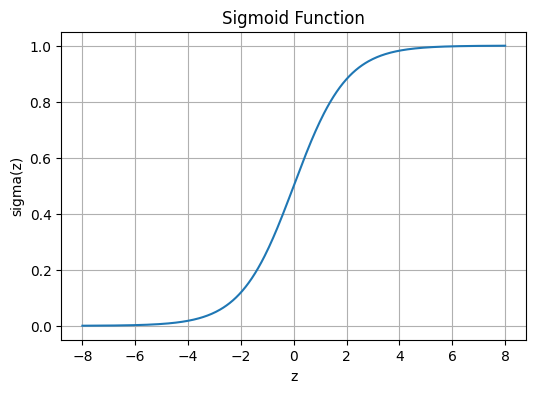

In [ ]:

# Visualize the sigmoid
z = np.linspace(-8, 8, 400)
sig = 1.0 / (1.0 + np.exp(-z))
plt.plot(z, sig)
plt.xlabel("z")
plt.ylabel("sigma(z)")
plt.title("Sigmoid Function")
plt.show()



### What this code does, line by line

- `z = np.linspace(-8, 8, 400)` — grid of input values.
- `sig = 1 / (1 + exp(-z))` — compute the logistic sigmoid.
- Plot `z` vs `sig`.

#### Mathematical step
$ \sigma(z) = 1/(1+e^{-z}) \in (0,1) $ maps real-valued scores to probabilities used in binary classification.

#### About $ z_i $

In logistic regression, the term $ z_i $ represents the **linear combination of the input features and model parameters** for the *i-th* training example.

Formally:
$$
z_i = x_i^\top \boldsymbol{\theta} = \theta_0 + \theta_1 x_{i1} + \theta_2 x_{i2} + \dots + \theta_d x_{id}.
$$

- $ z_i $ is the **raw linear score** before applying the sigmoid (logistic) function.
- It represents the **log-odds** (the logarithm of the odds ratio) of the predicted probability:
  $$
  \log\frac{\hat{p}_i}{1 - \hat{p}_i} = z_i.
  $$
- Passing $ z_i $ through the sigmoid function converts this linear score into a probability:
  $$
  \hat{p}_i = \sigma(z_i) = \frac{1}{1 + e^{-z_i}}.
  $$

---

#### Intuitive Interpretation

- $ z_i $ is a **weighted sum of inputs**, producing one scalar per observation.
- If $ z_i $ is **large and positive**, then $ \hat{p}_i \approx 1 $ (model predicts class 1).
- If $ z_i $ is **large and negative**, then $ \hat{p}_i \approx 0 $ (model predicts class 0).
- If $ z_i = 0 $, then $ \hat{p}_i = 0.5 $, meaning the model is uncertain.

---

#### Summary

- $ z_i $ is the **input to the sigmoid function**, bridging the linear model and probabilistic output.
- It is sometimes called the **logit** or **log-odds score**.
- Logistic regression transforms $ z_i $ via the sigmoid to produce probabilities, enabling binary classification while remaining linear in parameters.




## 9. Loss: Binary Cross-Entropy (Log Loss)

We derive the **binary cross-entropy (log loss)** used in logistic regression from first principles via **maximum likelihood**.

---

### Model and Parameterization

Let each label be $y_i \in \{0,1\}$ with features $x_i \in \mathbb{R}^d$, and define the linear score
$$
z_i = x_i^\top \boldsymbol{\theta}.
$$
Logistic regression models the class-1 probability with the **sigmoid**:
$$
\hat{p}_i \;=\; \Pr(y_i=1 \mid x_i;\boldsymbol{\theta}) \;=\; \sigma(z_i)
\;=\; \frac{1}{1 + e^{-z_i}}.
$$
Then $\Pr(y_i=0\mid x_i;\boldsymbol{\theta}) = 1 - \hat{p}_i$.

---

### Bernoulli Likelihood

Assuming i.i.d. samples, the conditional likelihood of the labels $y_1,\dots,y_n$ given $X$ and $\boldsymbol{\theta}$ is
$$
L(\boldsymbol{\theta})
= \prod_{i=1}^n \hat{p}_i^{\,y_i}\bigl(1-\hat{p}_i\bigr)^{(1-y_i)}.
$$
Taking logs (to turn products into sums) gives the **log-likelihood**:
$$
\ell(\boldsymbol{\theta})
= \sum_{i=1}^n \Bigl[\, y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \Bigr].
$$

---

### Negative Log-Likelihood = Cross-Entropy

We **maximize** $\ell(\boldsymbol{\theta})$. Equivalently, we **minimize** its negative (the average loss):
$$
J(\boldsymbol{\theta})
= -\frac{1}{n}\,\ell(\boldsymbol{\theta})
= -\frac{1}{n}\sum_{i=1}^n \Bigl[\, y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \Bigr].
$$
This is the **binary cross-entropy** (also called **log loss**).

---

### Expressing the Loss in Terms of $z_i$

Recall $\hat{p}_i = \sigma(z_i)$ and $1-\hat{p}_i = \sigma(-z_i)$.

Using
$\log \sigma(z) = -\log(1+e^{-z})$ and $\log(1-\sigma(z)) = -\log(1+e^{\,z})$,
we can write

$$
J(\boldsymbol{\theta})
= \frac{1}{n}\sum_{i=1}^n \Bigl[
\log\!\bigl(1+e^{-z_i}\bigr) + (1-y_i)\,z_i
\Bigr],
\quad \text{where } z_i=x_i^\top\boldsymbol{\theta}.
$$

A common alternative uses labels $\tilde{y}_i \in \{-1,+1\}$ with
$\tilde{y}_i = 2y_i-1$:

$$
J(\boldsymbol{\theta})
= \frac{1}{n}\sum_{i=1}^n \log\!\bigl(1 + e^{-\tilde{y}_i z_i}\bigr),
\qquad z_i = x_i^\top\boldsymbol{\theta}.
$$

This form highlights the **margin** $\tilde{y}_i z_i$.

---

### Gradient (First Derivative)

We consider the (average) logistic loss over $n$ examples:
$$
J(\boldsymbol{\theta}) \;=\; \frac{1}{n}\sum_{i=1}^{n} \ell_i(\boldsymbol{\theta}),
\qquad
\ell_i(\boldsymbol{\theta}) \;=\; -y_i\log \hat{p}_i \;-\; (1-y_i)\log(1-\hat{p}_i),
$$
with
$$
\hat{p}_i \;=\; \sigma(z_i) \;=\; \frac{1}{1+e^{-z_i}},
\qquad
z_i \;=\; x_i^\top \boldsymbol{\theta},
$$
and $x_i \in \mathbb{R}^{d+1}$ (augmented with a leading $1$ if an intercept is used), $\boldsymbol{\theta}\in\mathbb{R}^{d+1}$.

---

#### 1) Single-example derivative $\partial \ell_i / \partial z_i$

**Step A (outer derivative):** Differentiate $\ell_i$ w.r.t. $\hat{p}_i$:
$$
\frac{\partial \ell_i}{\partial \hat{p}_i}
= -\,\frac{y_i}{\hat{p}_i} \;+\; \frac{1-y_i}{1-\hat{p}_i}.
$$

**Step B (link derivative):** Differentiate $\hat{p}_i=\sigma(z_i)$ w.r.t. $z_i$:
$$
\frac{\partial \hat{p}_i}{\partial z_i}
= \hat{p}_i(1-\hat{p}_i).
$$

**Step C (chain rule):**
$$
\frac{\partial \ell_i}{\partial z_i}
= \frac{\partial \ell_i}{\partial \hat{p}_i}\cdot \frac{\partial \hat{p}_i}{\partial z_i}
= \Bigl(-\frac{y_i}{\hat{p}_i} + \frac{1-y_i}{1-\hat{p}_i}\Bigr)\,\hat{p}_i(1-\hat{p}_i).
$$

**Step D (algebraic simplification):**
$$
\begin{aligned}
\frac{\partial \ell_i}{\partial z_i}
&= -y_i(1-\hat{p}_i) \;+\; (1-y_i)\hat{p}_i \\
&= -y_i + y_i\hat{p}_i + \hat{p}_i - y_i\hat{p}_i \\
&= \hat{p}_i - y_i.
\end{aligned}
$$

Thus,
$$
\boxed{\;\frac{\partial}{\partial z_i}\bigl[-y_i\log \hat{p}_i -(1-y_i)\log(1-\hat{p}_i)\bigr] \;=\; \hat{p}_i - y_i.\;}
$$

---

#### 2) From $\partial \ell_i/\partial z_i$ to $\nabla_{\boldsymbol{\theta}} \ell_i$

Since $z_i = x_i^\top \boldsymbol{\theta}$,
$$
\frac{\partial z_i}{\partial \boldsymbol{\theta}} = x_i.
$$
By the chain rule,
$$
\nabla_{\boldsymbol{\theta}} \ell_i(\boldsymbol{\theta})
= \frac{\partial \ell_i}{\partial z_i}\,\frac{\partial z_i}{\partial \boldsymbol{\theta}}
= (\hat{p}_i - y_i)\,x_i.
$$

---

#### 3) Aggregate over all examples to get $\nabla_{\boldsymbol{\theta}} J$

Averaging over $n$ samples:
$$
\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})
= \frac{1}{n}\sum_{i=1}^{n} \nabla_{\boldsymbol{\theta}} \ell_i(\boldsymbol{\theta})
= \frac{1}{n}\sum_{i=1}^{n} (\hat{p}_i - y_i)\,x_i.
$$

---

#### 4) Matrix–vector form

Let
$$
X \in \mathbb{R}^{n\times(d+1)}
\quad\text{with rows } x_i^\top,\qquad
\hat{\mathbf{p}} = \sigma(X\boldsymbol{\theta}) \in \mathbb{R}^{n},\qquad
\mathbf{y}\in\mathbb{R}^{n}.
$$
Stacking the per-example terms yields:
$$
\boxed{\;\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})
= \frac{1}{n}\,X^\top\,(\hat{\mathbf{p}} - \mathbf{y})\;}
$$
which is the familiar gradient used in logistic regression training.

> **Shapes:**  
> $X$ is $(n\times(d{+}1))$, $\boldsymbol{\theta}$ is $((d{+}1)\times 1)$, $\hat{\mathbf{p}}-\mathbf{y}$ is $(n\times 1)$, so $X^\top(\hat{\mathbf{p}}-\mathbf{y})$ is $((d{+}1)\times 1)$.

---

#### Recap
Using $\partial \hat{p}_i / \partial z_i = \hat{p}_i(1-\hat{p}_i)$ and the chain rule:
- For a single example,
  $$
  \frac{\partial}{\partial z_i}\Bigl[-y_i\log \hat{p}_i -(1-y_i)\log(1-\hat{p}_i)\Bigr]
  = \hat{p}_i - y_i.
  $$
- Then by the chain rule $\partial z_i/\partial \boldsymbol{\theta} = x_i$,
  $$
  \nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})
  = \frac{1}{n}\sum_{i=1}^n (\hat{p}_i - y_i)\,x_i
  \;=\; \frac{1}{n}X^\top(\hat{\mathbf{p}} - \mathbf{y}),
  $$
  where $\hat{\mathbf{p}}=(\hat{p}_1,\dots,\hat{p}_n)^\top$.

This is the familiar gradient used in logistic regression training.

---

### Hessian (Second Derivative) and Convexity

For each $i$,
$$
\frac{\partial^2 J}{\partial z_i^2}
= \hat{p}_i(1-\hat{p}_i).
$$
Lifting to parameter space,
$$
\nabla^2_{\boldsymbol{\theta}} J(\boldsymbol{\theta})
= \frac{1}{n} \sum_{i=1}^n \hat{p}_i(1-\hat{p}_i)\, x_i x_i^\top
= \frac{1}{n} X^\top W X,
$$
where $W=\mathrm{diag}\bigl(\hat{p}_i(1-\hat{p}_i)\bigr)$ is positive semidefinite.  
Hence $J(\boldsymbol{\theta})$ is **convex** (globally), so any local minimum is global.

---

### Numerical Stability (Practical Note)

To avoid overflow/underflow when computing $\log \hat{p}_i$ and $\log(1-\hat{p}_i)$:
- Work directly with $z_i$ using **log-sum-exp**-style identities (as above).
- Clip probabilities in code: e.g., use $\hat{p}_i^\epsilon = \min(\max(\hat{p}_i,\epsilon), 1-\epsilon)$ with small $\epsilon$ (e.g., $10^{-12}$) before taking logs.

---

### Adding Regularization (Optional)

Regularization augments the loss to mitigate overfitting:
- **L2 (Ridge)**: $J_\lambda = J + \lambda \|\boldsymbol{\theta}\|_2^2$
- **L1 (Lasso)**: $J_\lambda = J + \lambda \|\boldsymbol{\theta}\|_1$

Gradients are adjusted accordingly (subgradients for L1).

---

### Summary

- Start with a **Bernoulli** model with $\hat{p}_i=\sigma(x_i^\top\boldsymbol{\theta})$.
- **Maximize** the log-likelihood $\ell(\boldsymbol{\theta})$ or **minimize** its negative.  For labels $ y \in \{0,1\} $, predictions $ \hat{p} = \sigma(\mathbf{x}^\top \boldsymbol{\theta}) $, the **average binary cross-entropy** is:
  $$
  J(\boldsymbol{\theta}) = -\frac{1}{n}\sum_{i=1}^n \bigl[ y_i\log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \bigr].
  $$
- The gradient is
  $$
  \nabla J = \frac{1}{n}X^\top(\hat{\mathbf{p}}-\mathbf{y}),
  $$
  and the Hessian is $(1/n)X^\top W X$, confirming **convexity**.
- This loss is the **binary cross-entropy**, the standard objective for probabilistic binary classification.



## 10. Logistic Regression from Scratch (Gradient Descent)

We start with the standard form of the logistic regression model:

$$
\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \theta_0 + \sum_{j=1}^{d}\theta_j x_j.
$$

Here:

- $\hat{p}$ is the predicted probability that $y = 1$.
- $\sigma(z)$ is the logistic (sigmoid) function.
- $z$ is a **linear combination** of the parameters $\theta_j$ and the input features $x_j$.
- $\theta_0$ is the intercept (bias term).
- $d$ is the number of features.

So, explicitly:

$$
z = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_d x_d.
$$

---

### Vector Form

We can represent this more compactly using vector notation.  
Define the augmented feature and parameter vectors:

$$
\mathbf{x} =
\begin{bmatrix}
1 \\
x_1 \\
x_2 \\
\vdots \\
x_d
\end{bmatrix},
\quad
\boldsymbol{\theta} =
\begin{bmatrix}
\theta_0 \\
\theta_1 \\
\theta_2 \\
\vdots \\
\theta_d
\end{bmatrix}.
$$

Then their dot product gives:

$$
\mathbf{x}^\top \boldsymbol{\theta}
= 1 \cdot \theta_0 + x_1 \theta_1 + \cdots + x_d \theta_d
= \theta_0 + \sum_{j=1}^{d}\theta_j x_j.
$$

Thus,

$$
z = \mathbf{x}^\top \boldsymbol{\theta}.
$$

In NumPy or Python, this is written as:

```python
z = X @ theta
```

where the `@` operator represents **matrix multiplication**.

---

### Matrix Form (Multiple Observations)

For $n$ data points (each with $d$ features), we construct a design matrix:

$$
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1d} \\
1 & x_{21} & x_{22} & \cdots & x_{2d} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{n1} & x_{n2} & \cdots & x_{nd}
\end{bmatrix}_{n \times (d+1)}.
$$

With the same parameter vector $\boldsymbol{\theta} \in \mathbb{R}^{(d+1) \times 1}$, we have:

$$
\mathbf{z} = X \boldsymbol{\theta}.
$$

This yields:

$$
\mathbf{z} =
\begin{bmatrix}
z_1 \\
z_2 \\
\vdots \\
z_n
\end{bmatrix},
\quad
z_i = \theta_0 + \sum_{j=1}^{d}\theta_j x_{ij}.
$$

The corresponding predicted probabilities for all samples are:

$$
\hat{\mathbf{p}} = \sigma(\mathbf{z}) = \frac{1}{1 + e^{-\mathbf{z}}}.
$$

In Python:

```python
z = X @ theta
p_hat = 1 / (1 + np.exp(-z))
```
---

### Summary

| Representation | Expression | Description |
|----------------|-------------|--------------|
| **Scalar (single data point)** | $z = \theta_0 + \sum_{j=1}^{d} \theta_j x_j$ | Linear combination with bias term |
| **Vector (single data point)** | $z = \mathbf{x}^\top \boldsymbol{\theta}$ | Dot product form |
| **Matrix (multiple data points)** | $\mathbf{z} = X \boldsymbol{\theta}$ | Matrix multiplication for all samples |

Hence,  

$$
z = X \theta
$$  

is simply the **matrix–vector form** of  

$$
z = \theta_0 + \sum_{j=1}^{d}\theta_j x_j,
$$  

---

### Recap

We implement logistic regression on a synthetic 2D dataset and visualize the decision boundary.

- $ \theta_0 $ — the **intercept**, shifting the sigmoid horizontally.  
- $ \theta_j $ — the **weight** for feature $ x_j $; positive values push the probability toward 1 as $ x_j $ increases, negative toward 0.  
- The model predicts probability via the sigmoid:
  $$
  \hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \theta_0 + \sum_{j=1}^{d}\theta_j x_j.
  $$

Thus, the fitted logistic regression equation describes how the **linear score**
$ z = x^\top\boldsymbol{\theta} $ is converted into the predicted probability of belonging to class 1.


Final loss: 0.19524410232158296


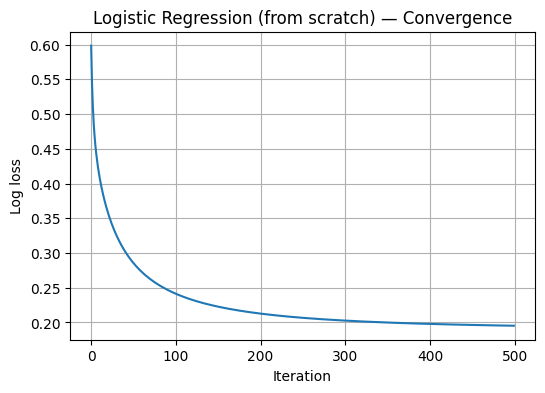

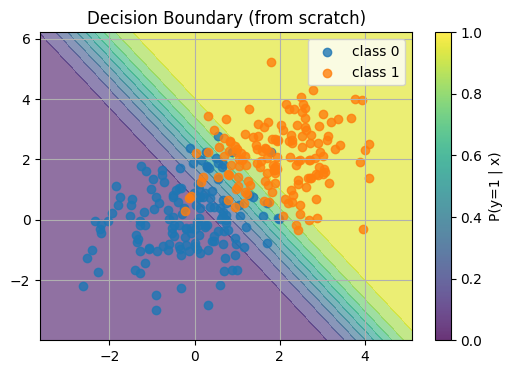

In [ ]:

# Synthetic binary classification data
n = 300
mean0, mean1 = np.array([0, 0]), np.array([2, 2])
cov = np.array([[1.0, 0.2],[0.2, 1.0]])
X0 = np.random.multivariate_normal(mean0, cov, size=n//2)
X1 = np.random.multivariate_normal(mean1, cov, size=n//2)
X_bin = np.vstack([X0, X1])
y_bin = np.hstack([np.zeros(n//2, dtype=int), np.ones(n//2, dtype=int)])

# Shuffle
perm = np.random.permutation(n)
X_bin, y_bin = X_bin[perm], y_bin[perm]

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_loss(theta, X, y):
    z = X @ theta
    p = sigmoid(z)
    eps = 1e-12
    return -np.mean(y * np.log(p + eps) + (1-y)*np.log(1 - p + eps))

def logistic_gd(X, y, lr=0.1, steps=500):
    theta = np.zeros(X.shape[1])
    history = []
    for t in range(steps):
        z = X @ theta
        p = sigmoid(z)
        grad = X.T @ (p - y) / len(y)
        theta -= lr * grad
        history.append(logistic_loss(theta, X, y))
    return theta, np.array(history)

# Add intercept term
X_aug = np.c_[np.ones((n, 1)), X_bin]
theta, hist = logistic_gd(X_aug, y_bin, lr=0.2, steps=500)

print("Final loss:", hist[-1])

plt.plot(hist)
plt.xlabel("Iteration")
plt.ylabel("Log loss")
plt.title("Logistic Regression (from scratch) — Convergence")
plt.show()

# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X_bin[:,0].min()-1, X_bin[:,0].max()+1, 200),
                     np.linspace(X_bin[:,1].min()-1, X_bin[:,1].max()+1, 200))
grid = np.c_[np.ones((xx.size, 1)), xx.ravel(), yy.ravel()]
probs = sigmoid(grid @ theta).reshape(xx.shape)

plt.contourf(xx, yy, probs, levels=np.linspace(0,1,11), alpha=0.6)
plt.scatter(X_bin[y_bin==0,0], X_bin[y_bin==0,1], label="class 0", alpha=0.8)
plt.scatter(X_bin[y_bin==1,0], X_bin[y_bin==1,1], label="class 1", alpha=0.8)
plt.colorbar(label="P(y=1 | x)")
plt.legend(); plt.title("Decision Boundary (from scratch)")
plt.show()



### What this code does, line by line

**Data generation**  
- Build two Gaussian clusters (`mean0`, `mean1`) with shared covariance `cov` for classes 0 and 1.
- Stack points and labels, then randomly permute to shuffle.

**Model primitives**  
- `sigmoid(z)` — logistic link for probabilities.
- `logistic_loss(theta, X, y)` — average binary cross-entropy with small `eps` for numerical stability.

**Training loop**  
- Add intercept column: `X_aug = [1, x₁, x₂]`.
- `logistic_gd`:
  - Initialize `θ = 0`.
  - At each step:
    - `z = Xθ`, `p = σ(z)` — predicted probabilities.
    - Gradient of log loss: `∇ = Xᵀ(p - y)/n`.
    - Update: `θ ← θ - α ∇`.
  - Track objective to verify convergence.

**Visualization**  
- Plot the loss trajectory vs iterations.
- Build a meshgrid in feature space, compute `P(y=1|x)` for each grid point, and plot filled contours as a probability map.
- Overlay samples for both classes and a colorbar.

#### Mathematical step
Binary cross-entropy: $ J(θ) = -\tfrac{1}{n}\sum [y\log p + (1-y)\log(1-p)] $, with $ p = \sigma(Xθ) $.
Gradient: $ \nabla J = X^\top(p - y)/n $.


## 11. Visualizing True Labels and Predicted Probabilities on the Sigmoid Curve

Now that we've trained the logistic regression model, we can visualize how well it separates the two classes.  
We'll plot:

1. The **sigmoid curve** estimated by the model.  
2. The **data points**, showing:
   - True class labels (0 or 1)
   - Their predicted probabilities from the model.

This helps us see how the model's linear score $ z_i = x_i^\top \boldsymbol{\theta} $ is transformed into probabilities $ \hat{p}_i = \sigma(z_i) $,  
and how accurately it classifies the training samples.

### Interpretation

- The **blue sigmoid curve** represents the model's estimate of $ P(y=1 \mid x) $.  
- The **colored dots (red/blue)** represent the true binary class labels from the data.  
- The **black X's** represent the predicted probabilities for each training point.

You should observe that:
- Points labeled **1** tend to cluster where the sigmoid output is near 1.  
- Points labeled **0** cluster where the sigmoid output is near 0.  
- The **transition region** around the middle of the sigmoid marks the model's decision boundary, where $ P(y=1|x) = 0.5 $.

This plot provides a geometric and probabilistic picture of how logistic regression maps input values $ x $ to predicted class probabilities via the sigmoid function.

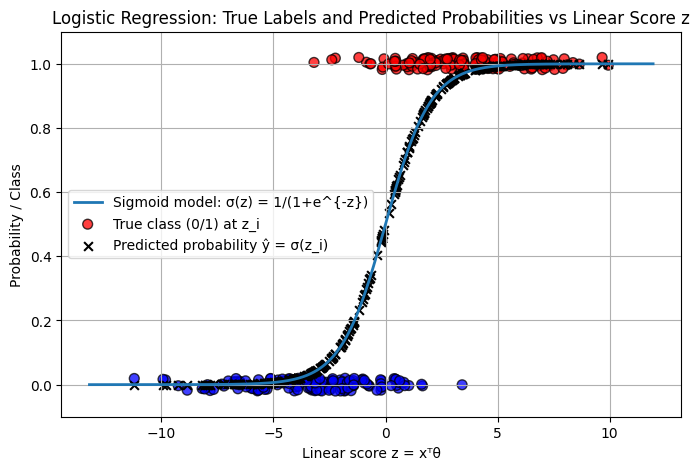

Fitted parameters (theta): [-3.10859073  1.99054369  1.31831269]

Estimated logistic model:
 log( p / (1 - p) ) = -3.109 + 1.991*x1 + 1.318*x2


In [ ]:
# Assumes from Step 10:
# - X_bin: shape (n, 2), the 2D synthetic features
# - y_bin: shape (n,), binary labels {0,1}
# - X_aug: shape (n, 3) with an intercept column: X_aug = np.c_[np.ones((n, 1)), X_bin]
# - theta: shape (3,), learned by logistic_gd
# - sigmoid(z) function is already defined

# Compute linear scores z_i and predicted probabilities p_i
z = X_aug @ theta                 # shape (n,)
p = sigmoid(z)                    # predicted P(y=1 | x)

# Prepare a smooth grid over z to draw the sigmoid curve
z_grid = np.linspace(z.min() - 2, z.max() + 2, 400)
sig_grid = sigmoid(z_grid)

plt.figure(figsize=(8, 5))

# 1) Plot the model's sigmoid in (z, sigma(z)) space
plt.plot(z_grid, sig_grid, linewidth=2, label="Sigmoid model: σ(z) = 1/(1+e^{-z})")

# 2) Plot true labels at their corresponding z positions (with tiny jitter for visibility)
rng = np.random.default_rng(0)
jitter = (rng.random(len(y_bin)) - 0.5) * 0.04  # small vertical jitter
plt.scatter(z, y_bin + jitter, s=50, alpha=0.75, edgecolor="k",
            label="True class (0/1) at z_i", c=y_bin, cmap="bwr")

# 3) Plot predicted probabilities at the same z positions
plt.scatter(z, p, s=40, marker="x", color="black", label="Predicted probability ŷ = σ(z_i)")

# Formatting
plt.title("Logistic Regression: True Labels and Predicted Probabilities vs Linear Score z")
plt.xlabel("Linear score z = xᵀθ")
plt.ylabel("Probability / Class")
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

# θ includes the intercept θ₀ followed by one weight per feature (θ₁, θ₂, …)
print("Fitted parameters (theta):", theta)

# Example equation for the model:
# log-odds( P(y=1 | x) ) = θ₀ + θ₁*x₁ + θ₂*x₂ + … + θ_d*x_d
eq_terms = [f"{theta[j]:.3f}*x{j}" for j in range(1, len(theta))]
equation = f"log( p / (1 - p) ) = {theta[0]:.3f} + " + " + ".join(eq_terms)
print("\nEstimated logistic model:\n", equation)


## 12. Scikit‑learn Logistic Regression on a Real Dataset

We use the **Breast Cancer Wisconsin** dataset, which contains the following features mapped to a benign/malignant binary classification.

| # | Base Feature | Description |
|---|---------------|--------------|
| 1 | **radius** | Mean distance from the center to points on the perimeter |
| 2 | **texture** | Standard deviation of gray-scale values |
| 3 | **perimeter** | Perimeter of the cell nucleus |
| 4 | **area** | Area of the cell nucleus |
| 5 | **smoothness** | Local variation in radius lengths |
| 6 | **compactness** | $ \frac{(\text{perimeter})^2}{\text{area}} - 1.0 $ |
| 7 | **concavity** | Severity of concave portions of the contour |
| 8 | **concave points** | Number of concave portions of the contour |
| 9 | **symmetry** | Symmetry of the nucleus |
| 10 | **fractal dimension** | Coastline approximation (a measure of boundary complexity) |


Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



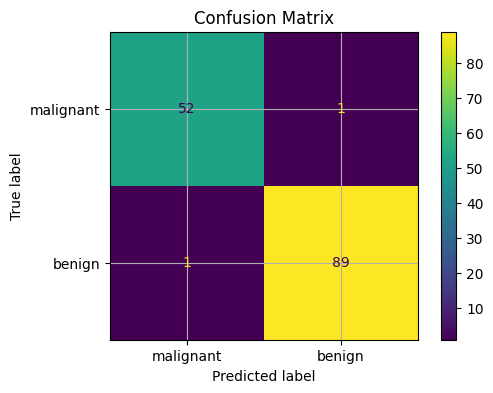

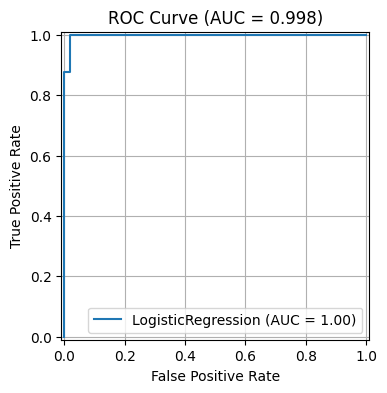

In [ ]:

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("logreg", LogisticRegression(max_iter=500, C=1.0)) # C is inverse regularization strength
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:,1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant","benign"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="LogisticRegression").plot()
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.show()



### What this code does, line by line

- Load the Breast Cancer Wisconsin dataset into `(X, y)` with `y ∈ {0,1}`.
- Stratified `train_test_split` preserves label proportions in both splits.
- Pipeline: `StandardScaler` → `LogisticRegression(max_iter=500, C=1.0)`.
- Fit on training data; compute:
  - `y_pred` — hard labels using the default 0.5 threshold.
  - `y_prob` — predicted probability for the positive class.
- `classification_report` — precision/recall/F1 for each class and macro/weighted averages.
- `confusion_matrix` and `ConfusionMatrixDisplay` — counts of TP, FP, TN, FN (display labels set to malignant/benign).
- ROC/AUC:
  - `roc_curve(y_test, y_prob)` — sweep threshold to get `fpr`, `tpr`.
  - `auc(fpr, tpr)` — area under the ROC curve.
  - Plot ROC with title embedding the numeric AUC.

#### Mathematical step
Logistic regression with L2 regularization solves $ \min_θ \; -\sum \log p(y|x;θ) + \lambda \|θ\|_2^2 $.  
AUC summarizes ranking quality independent of a specific threshold.

---

### Understanding F1 Score and Support

When evaluating a **classification model**, we often look beyond accuracy to metrics that consider the balance between correctly predicting positive and negative classes.  
Two of these are the **F1 score** and **support**.

---

#### 1. The Confusion Matrix Foundation

All classification metrics are based on the **confusion matrix**, which summarizes predictions versus actual labels:

|                | **Predicted Positive** | **Predicted Negative** |
|----------------|------------------------|------------------------|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

From this, we define:

- **Precision**: fraction of predicted positives that are truly positive  
  $$
  \text{Precision} = \frac{TP}{TP + FP}
  $$

- **Recall (Sensitivity)**: fraction of actual positives that are correctly identified  
  $$
  \text{Recall} = \frac{TP}{TP + FN}
  $$

---

#### 2. F1 Score

The **F1 score** is the **harmonic mean** of precision and recall.  
It balances the two: high F1 means the classifier has both high precision and high recall.

$$
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**Key properties:**
- $ F_1 \in [0,1] $
- $ F_1 = 1 $ is perfect precision and recall.
- It **penalizes extreme imbalance**: if one of precision or recall is very low, $ F_1 $ drops sharply.
- Particularly useful when the dataset is **imbalanced**, i.e., one class occurs much more frequently than the other.

**Example:**
If a model identifies 80% of all true positives (recall = 0.8) and 70% of its positive predictions are correct (precision = 0.7), then
$$
F_1 = 2 \times \frac{0.7 \times 0.8}{0.7 + 0.8} = 0.746.
$$

---

#### 3. Support

The **support** for a class is simply the **number of true instances** of that class in the dataset.

$$
\text{Support(class } i\text{)} = \text{number of samples with } y = i
$$

In `sklearn.metrics.classification_report`, support tells you how many test examples there are for each class:

```
              precision    recall  f1-score   support
           0       0.91      0.89      0.90       120
           1       0.84      0.87      0.86        80
```

Here:
- Support for class 0 = 120 (there were 120 true negatives)
- Support for class 1 = 80 (there were 80 true positives)

Support isn’t a performance metric—it’s a **count**—but it’s important because it shows the **class distribution**.  
If support is highly uneven, metrics like accuracy can be misleading, while the F1 score remains more informative.

---

#### 4. Summary Table

| Metric | Formula | Measures | Best Value | Notes |
|---------|----------|-----------|-------------|--------|
| **Precision** | $ TP / (TP + FP) $ | Correctness of positive predictions | 1.0 | High precision = few false alarms |
| **Recall** | $ TP / (TP + FN) $ | Coverage of actual positives | 1.0 | High recall = few missed positives |
| **F1 Score** | $ 2 \times \frac{PR}{P + R} $ | Harmonic mean of precision & recall | 1.0 | Balances false positives & false negatives |
| **Support** | Count of true instances per class | Data distribution | — | Not a score; contextual information |

---

#### 5. When to Use F1 Score

- When class distribution is **uneven** (e.g., 90% negatives, 10% positives).  
- When **false positives and false negatives** have similar costs.  
- When you want a **single metric** summarizing precision–recall trade-off.

---

**In short:**  
> The **F1 score** balances precision and recall into one interpretable number,  
> while **support** tells you how many samples there are in each true class,  
> providing essential context for understanding your model’s performance.

---

### Understanding ROC and AUC in the Breast Cancer Example

When evaluating the logistic regression model on the Breast Cancer dataset, we often go beyond accuracy to understand how well the model distinguishes between the two classes — **malignant (0)** and **benign (1)**.  
The **Receiver Operating Characteristic (ROC)** curve and the **Area Under the Curve (AUC)** provide a powerful, threshold-independent way to measure this.

---

#### 1. The Idea Behind ROC Curves

The logistic regression model outputs a **probability** $ \hat{p}_i = P(y_i = 1 | x_i) $ for each sample.  
To make a classification, we must choose a **threshold** (typically 0.5):
- If $ \hat{p}_i \ge 0.5 $, predict class 1 (benign)
- If $ \hat{p}_i < 0.5 $, predict class 0 (malignant)

However, the choice of threshold affects **how sensitive or specific** the classifier is.

To explore performance across **all possible thresholds**, we vary the threshold $ t $ from 0 to 1 and record:

| Metric | Formula | Interpretation |
|---------|----------|----------------|
| **True Positive Rate (TPR)** | $ \frac{TP}{TP + FN} $ | Probability of correctly detecting a positive case (Recall or Sensitivity) |
| **False Positive Rate (FPR)** | $ \frac{FP}{FP + TN} $ | Probability of incorrectly labeling a negative case as positive |

By plotting **TPR** (y-axis) versus **FPR** (x-axis) for all thresholds, we get the **ROC curve**.

---

#### 2. Reading the ROC Curve

- A perfect classifier: ROC curve hugs the **top-left corner** → TPR = 1, FPR = 0.
- A random classifier: ROC curve lies along the **diagonal line** (TPR = FPR).
- The closer the ROC curve is to the top-left corner, the better the classifier separates the two classes.

---

#### 3. AUC: Area Under the ROC Curve

The **AUC (Area Under the Curve)** is a scalar summary of the ROC curve — it measures the probability that the classifier will rank a randomly chosen positive sample higher than a randomly chosen negative one.

Formally:
$$
\text{AUC} = P(\hat{p}_{\text{positive}} > \hat{p}_{\text{negative}}).
$$

**Interpretation:**

| AUC Value | Meaning |
|------------|----------|
| 1.0 | Perfect classification |
| 0.9–1.0 | Excellent discrimination |
| 0.8–0.9 | Good |
| 0.7–0.8 | Fair |
| 0.5 | No discriminative ability (random guessing) |

---

#### 4. Computing and Plotting ROC AUC in Python

You can compute and visualize the ROC and AUC as follows:

```python
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities for the positive class (benign)
y_prob = pipe.predict_proba(X_test)[:, 1]

# Compute ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC (test set): {auc:.3f}")

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", linewidth=2, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Logistic Regression on Breast Cancer Dataset")
plt.legend()
plt.grid(True)
plt.show()
```

---

#### 5. Interpretation for the Breast Cancer Model

You’ll typically see an **AUC around 0.98–0.99** for the logistic regression model on this dataset.  
This means the classifier can correctly rank a malignant vs. benign sample about **98–99% of the time**, indicating **excellent separability** between the two classes.

- The ROC curve will rise steeply toward the top-left corner.
- The model achieves high recall (detects most malignant tumors) while keeping false positives low.

---

#### 6. Why ROC AUC is Useful

- **Threshold-independent:** Evaluates the model across *all* possible thresholds, unlike accuracy or F1, which depend on one threshold (usually 0.5).  
- **Robust to class imbalance:** Works well even when classes are unequally represented (as in many medical datasets).
- **Intuitive probabilistic meaning:** Measures the model’s ability to correctly order samples by risk.

---

**In summary:**  
> The ROC curve shows how sensitivity and specificity trade off as you vary the classification threshold,  
> while the AUC quantifies the model’s overall ability to discriminate between malignant and benign tumors.  
> In this Breast Cancer example, a high AUC (>0.98) confirms that logistic regression is an exceptionally effective linear classifier for this dataset.




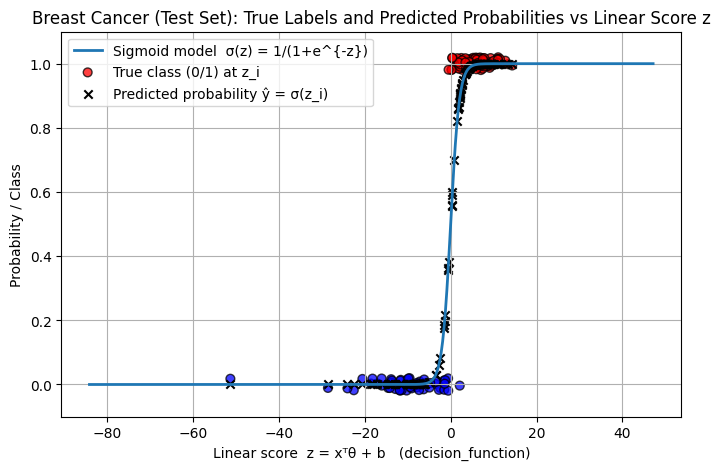

Fitted logistic parameters (on STANDARDIZED features):
  θ₀ (intercept) = 0.280555
  ‖θ‖₂           = 3.518419
  First few weights: [-0.5231, -0.5187, -0.4837, -0.5573, -0.301 ,  0.6942]

Fitted logistic parameters (on ORIGINAL feature scales):
  θ₀ (intercept) = 34.628168
  ‖θ‖₂           = 169.364182
  First few weights: [-1.4924e-01, -1.1675e-01, -2.0023e-02, -1.6130e-03, -2.2581e+01,
  1.3197e+01]

Estimated logistic model on ORIGINAL features:
 log( p / (1 - p) ) = 34.6282 + -0.1492*mean radius + -0.1167*mean texture + -0.0200*mean perimeter + -0.0016*mean area + -22.5814*mean smoothness + 13.1973*mean compactness + -6.9944*mean concavity + -17.6026*mean concave points + -4.5716*mean symmetry + 11.5825*mean fractal dimension + -4.0684*radius error + 0.4579*texture error + -0.2519*perimeter error + -0.0228*area error + -47.1912*smoothness error + 33.3473*compactness error + 4.6991*concavity error + -54.3002*concave points error + 47.9814*symmetry error + 132.0277*fractal dimension 

In [ ]:
# Visualizing the breast cancer dataset

# 1) Load data and split
data = load_breast_cancer()
X = data.data                  # shape (n_samples, 30)
y = data.target                # 0 = malignant, 1 = benign
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 2) Fit a well-conditioned logistic regression (scale + higher max_iter)
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("logreg", LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs"))
])
pipe.fit(X_train, y_train)

# 3) Compute linear score z and probabilities on the TEST set
# For binary LogisticRegression, decision_function returns the raw logit (z = x^T theta + b).
z_test = pipe.decision_function(X_test)          # shape (n_test,)
p_test = pipe.predict_proba(X_test)[:, 1]        # P(y=1 | x)

# 4) Prepare a smooth grid in z and draw the sigmoid curve σ(z)
z_min = z_test.min()
z_max = z_test.max()
padding = 0.5 * (z_max - z_min + 1e-9)
z_grid = np.linspace(z_min - padding, z_max + padding, 400)
sigmoid = lambda z: 1.0 / (1.0 + np.exp(-z))
sig_grid = sigmoid(z_grid)

# 5) Plot: sigmoid curve; true labels at (z_i, y_i) with small jitter; predicted probs at (z_i, p_i)
plt.figure(figsize=(8, 5))

# Sigmoid model curve
plt.plot(z_grid, sig_grid, linewidth=2, label="Sigmoid model  σ(z) = 1/(1+e^{-z})")

# True labels (0/1) vs their z positions (add tiny vertical jitter for visibility)
rng = np.random.default_rng(0)
jitter = (rng.random(len(y_test)) - 0.5) * 0.04
plt.scatter(z_test, y_test + jitter, s=40, alpha=0.75, edgecolor="k",
            label="True class (0/1) at z_i", c=y_test, cmap="bwr")

# Predicted probabilities at the same z positions
plt.scatter(z_test, p_test, s=36, marker="x", color="black",
            label="Predicted probability ŷ = σ(z_i)")

plt.title("Breast Cancer (Test Set): True Labels and Predicted Probabilities vs Linear Score z")
plt.xlabel("Linear score  z = xᵀθ + b   (decision_function)")
plt.ylabel("Probability / Class")
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

# 6) Print the learned parameters in a readable form.
#    For a pipeline, get intercept_ and coef_ from the final estimator.
logreg = pipe.named_steps["logreg"]
scaler = pipe.named_steps["scaler"]

# --- Fix deprecation: extract scalar explicitly ---
theta0_std = logreg.intercept_.item()      # scalar intercept in standardized space
theta_std = logreg.coef_.ravel()           # shape (n_features,) in standardized space

print("Fitted logistic parameters (on STANDARDIZED features):")
print(f"  θ₀ (intercept) = {theta0_std:.6f}")
print(f"  ‖θ‖₂           = {np.linalg.norm(theta_std):.6f}")
print("  First few weights:", np.array2string(theta_std[:6], precision=4, separator=", "))

# --- Optional: convert coefficients back to ORIGINAL feature space ---
# StandardScaler: x_std = (x - mean_) / scale_
# z_std = θ₀_std + Σ_j θ_std_j * x_std_j
#      = [θ₀_std - Σ_j θ_std_j * mean_j/scale_j] + Σ_j (θ_std_j/scale_j) * x_j
# So:
theta_orig = theta_std / scaler.scale_
theta0_orig = theta0_std - np.sum(theta_std * scaler.mean_ / scaler.scale_)

print("\nFitted logistic parameters (on ORIGINAL feature scales):")
print(f"  θ₀ (intercept) = {theta0_orig:.6f}")
print(f"  ‖θ‖₂           = {np.linalg.norm(theta_orig):.6f}")
print("  First few weights:", np.array2string(theta_orig[:6], precision=4, separator=", "))

# Optional: print explicit log-odds equation using feature names (original scale)
terms_orig = [f"{theta_orig[j]:.4f}*{data.feature_names[j]}" for j in range(len(theta_orig))]
equation_orig = "log( p / (1 - p) ) = " + f"{theta0_orig:.4f} + " + " + ".join(terms_orig)
print("\nEstimated logistic model on ORIGINAL features:\n", equation_orig)

## 13. Regularization & the Role of **C**

`LogisticRegression` uses L2 regularization by default. The parameter **`C`** is the **inverse** of regularization strength (larger `C` → less regularization). We sweep `C` to observe its effect.


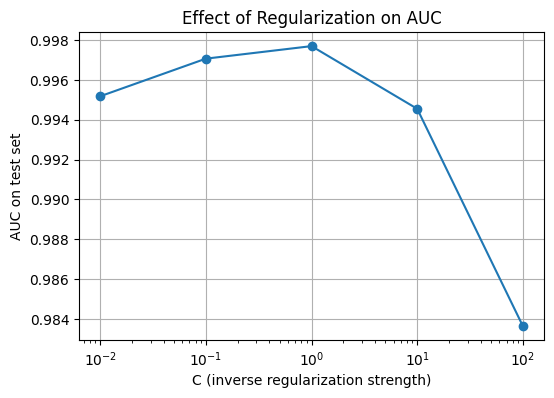

In [ ]:

Cs = [0.01, 0.1, 1.0, 10.0, 100.0]
aucs = []

for C in Cs:
    clf = Pipeline([("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=500, C=C))])
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    aucs.append(auc(fpr, tpr))

plt.plot(Cs, aucs, marker="o")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("AUC on test set")
plt.title("Effect of Regularization on AUC")
plt.show()



### What this code does, line by line

- Define a grid of regularization parameters via `C ∈ {0.01, 0.1, 1, 10, 100}` (note: larger `C` ⇒ weaker regularization).
- For each `C`:
  - Refit the standardized logistic model on the same train split.
  - Compute AUC on the test split and store it.
- Plot AUC vs `C` on a log-x scale.

#### Mathematical step
`C = 1/λ`. Over-regularization (small `C`) can underfit; too little regularization (large `C`) can overfit. The curve helps choose a reasonable trade-off.


## 14. Multiclass Logistic Regression (Softmax) with Iris

For more than two classes, scikit‑learn uses an OvR (one‑vs‑rest) or multinomial (softmax) formulation. Here we use `multi_class='auto'`.


Test accuracy (Iris, 2 features): 0.763


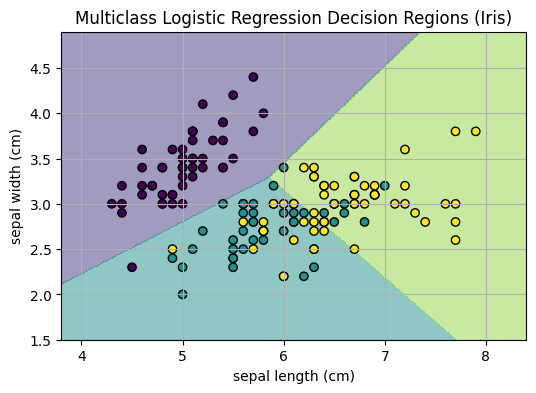

In [ ]:

iris = load_iris()
X = iris.data[:, :2]  # use 2 features for visualization
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = Pipeline([("scaler", StandardScaler()),
                ("logreg", LogisticRegression(max_iter=500))])
clf.fit(X_train, y_train)
acc = clf.score(X_test, y_test)
print(f"Test accuracy (Iris, 2 features): {acc:.3f}")

# Plot decision regions
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.5, levels=np.arange(4)-0.5)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")
plt.xlabel(iris.feature_names[0]); plt.ylabel(iris.feature_names[1])
plt.title("Multiclass Logistic Regression Decision Regions (Iris)")
plt.show()



### What this code does, line by line

- Load Iris and take the first two features for 2D visualization.
- Stratified train/test split.
- Pipeline: standardize → multinomial/ovr logistic regression (auto selection).
- `clf.score` reports accuracy on the test set.
- Decision regions:
  - Build a dense grid in the 2D feature plane.
  - Predict class on each grid point and reshape to the grid.
  - `contourf` to visualize predicted regions, then scatter the true points with class-colored markers.
- Axis labels use the dataset's feature names.

#### Mathematical step
Multiclass logistic regression maximizes the multinomial log-likelihood with softmax:
$ p(y=k|x) = \frac{\exp(θ_k^\top x)}{\sum_j \exp(θ_j^\top x)} $.



### Exercises

1. **Threshold tuning:** By default, we predict class 1 if `p >= 0.5`. Change the threshold and see how precision/recall trade off.
2. **Class imbalance:** Create an imbalanced synthetic dataset (e.g., 90% of one class). Compare AUC, accuracy, and F1. Try `class_weight='balanced'`.
3. **Regularization path:** Sweep `C` more finely, and visualize coefficients vs. `C` on the breast cancer dataset.
4. **Feature subsets:** On the breast cancer dataset, try using only a subset of features. Does performance change significantly?



---
## 15. Summary

- **Linear regression** models a continuous response, typically optimized via MSE (closed form or gradient methods), and benefits from regularization and diagnostics.
- **Logistic regression** models **probabilities** for classification, optimized via cross-entropy, and is evaluated using ROC/AUC, confusion matrices, and precision/recall/F1.
- Both are **generalized linear models** with different link functions (identity vs. logit).
